# GARCH Volatility Features

**Docker image**: `ml4t`

This notebook extracts volatility features from GARCH family models:
conditional volatility, persistence parameters, and leverage effects.

**Learning Objectives**:
- Test for ARCH effects using Engle's LM test
- Fit GARCH(1,1) and EGARCH(1,1,1) models
- Extract conditional volatility and persistence features
- Interpret the stationarity constraint ($\alpha + \beta < 1$)

**Book Reference**: Chapter 9, Section 9.3 (Volatility Features)

**Prerequisites**: `07_arima_features` for the ARIMA residual pipeline that
feeds into GARCH estimation.

In [1]:
"""GARCH Volatility Features — extract conditional volatility and persistence from GARCH family models."""

import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# ARCH library
from arch import arch_model
from IPython.display import display

# ml4t libraries
from ml4t.diagnostic.evaluation.volatility import arch_lm_test
from ml4t.diagnostic.evaluation.volatility import fit_garch as ml4t_fit_garch
from ml4t.engineer.features.volatility import (
    ewma_volatility,
    garch_forecast,
    realized_volatility,
    volatility_of_volatility,
    volatility_percentile_rank,
    volatility_regime_probability,
)
from scipy.stats import probplot

# Statistical tests
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

warnings.filterwarnings("ignore", category=FutureWarning)

from data import load_etfs
from utils.paths import get_case_study_dir

.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all symbols
START_DATE = "2010-01-01"
END_DATE = "2024-12-31"

## Load Data

We use ETF universe returns which exhibit well-known volatility clustering.
SPY is used for the detailed demonstration; multiple symbols are processed for output.

In [3]:
# Configuration
etf_data = load_etfs()
ALL_SYMBOLS = etf_data["symbol"].unique().sort().to_list()

SYMBOLS = ALL_SYMBOLS[:MAX_SYMBOLS] if MAX_SYMBOLS > 0 else ALL_SYMBOLS
start_date = datetime.strptime(START_DATE, "%Y-%m-%d")

end_date = datetime.strptime(END_DATE, "%Y-%m-%d")

# Primary symbol for detailed demonstration
SYMBOL = "SPY"

print("GARCH Volatility Configuration:")
print(f"  Symbols: {len(SYMBOLS)} ({', '.join(SYMBOLS[:5])}{'...' if len(SYMBOLS) > 5 else ''})")
print(f"  Date range: {start_date.date()} to {end_date.date()}")

# Filter to date range and primary symbol for demonstration
etf_filtered = etf_data.filter(
    (pl.col("timestamp") >= start_date.date()) & (pl.col("timestamp") <= end_date.date())
).sort("timestamp")


def load_symbol_returns(symbol: str) -> pd.Series | None:
    """Load returns for a single symbol from ETF universe."""
    symbol_data = (
        etf_filtered.filter(pl.col("symbol") == symbol)
        .select(["timestamp", "close"])
        .with_columns(returns=pl.col("close").log().diff() * 100)  # Scaled for GARCH
        .drop_nulls()
    )

    if len(symbol_data) < 252:
        return None

    df = symbol_data.to_pandas().set_index("timestamp")
    df.index = pd.DatetimeIndex(df.index)
    return df["returns"]


# Load primary symbol for demonstration
returns = load_symbol_returns(SYMBOL)
assert returns is not None, f"Missing sufficient data for {SYMBOL}"
print(f"\n{SYMBOL} Returns: {len(returns)} observations")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")
print(f"Mean: {returns.mean():.4f}%, Std: {returns.std():.4f}%")

GARCH Volatility Configuration:
  Symbols: 100 (ACWI, ACWX, AGG, BIL, BND...)
  Date range: 2010-01-01 to 2024-12-31

SPY Returns: 3773 observations
Date range: 2010-01-05 00:00:00 to 2024-12-31 00:00:00
Mean: 0.0509%, Std: 1.0772%


## Test for ARCH Effects

Before fitting a GARCH model, we test whether the squared residuals exhibit
serial correlation (ARCH effects). This validates the need for a volatility model.

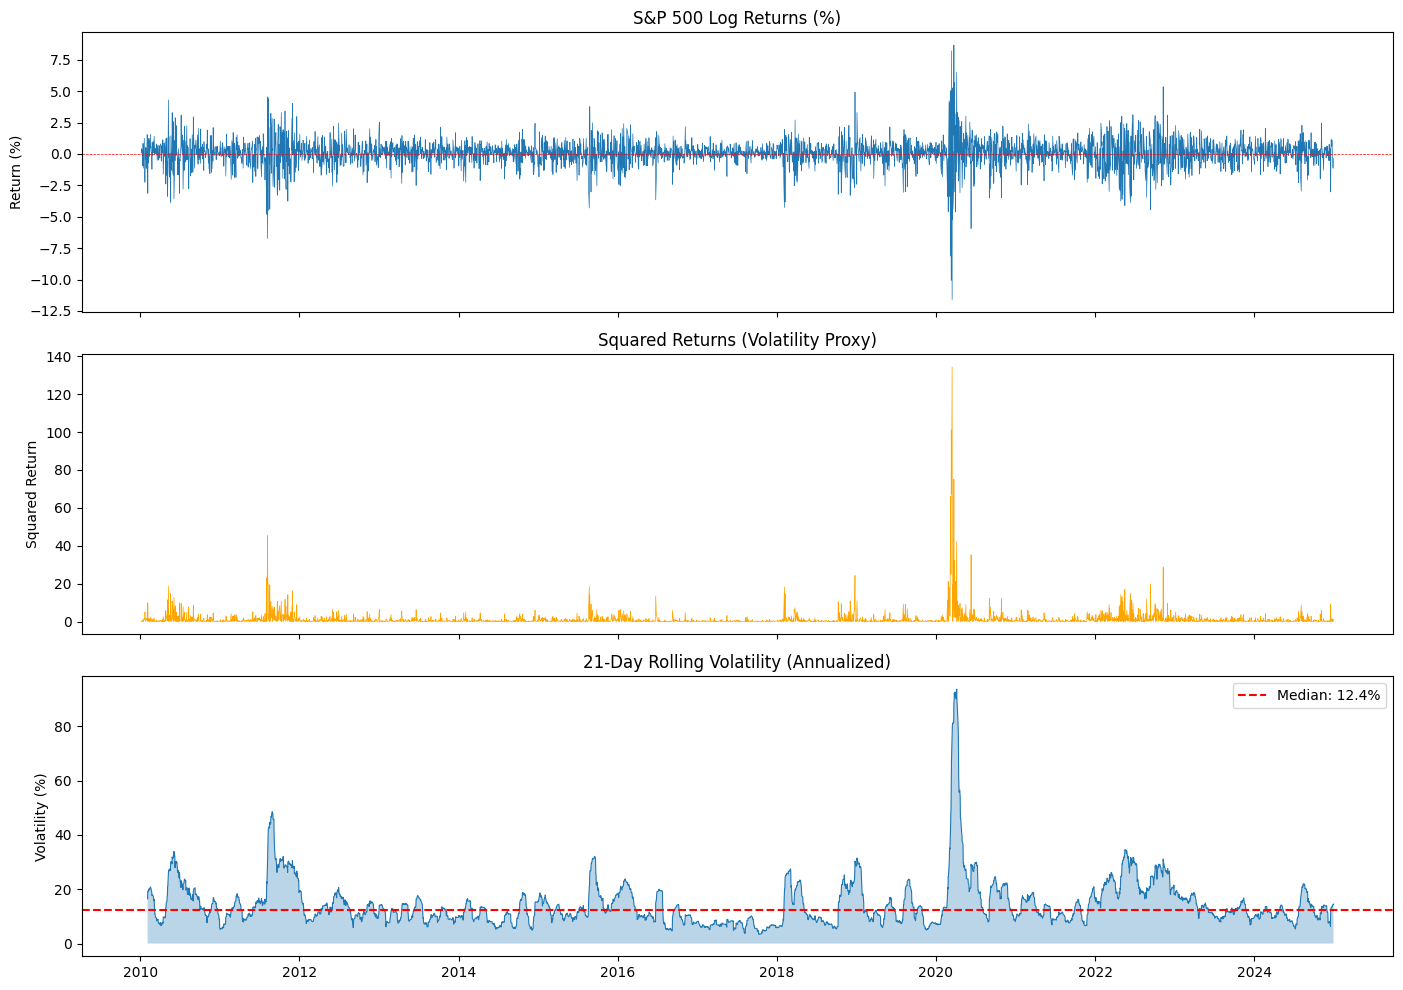

In [4]:
# Visual inspection: squared returns show clustering
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Returns
ax = axes[0]
ax.plot(returns.index, returns.values, linewidth=0.5)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("S&P 500 Log Returns (%)")
ax.set_ylabel("Return (%)")

# Squared returns (proxy for volatility)
squared_returns = returns**2
ax = axes[1]
ax.plot(squared_returns.index, squared_returns.values, linewidth=0.5, color="orange")
ax.set_title("Squared Returns (Volatility Proxy)")
ax.set_ylabel("Squared Return")

# Rolling volatility
rolling_vol = returns.rolling(21).std() * np.sqrt(252)
ax = axes[2]
ax.fill_between(rolling_vol.index, 0, rolling_vol.values, alpha=0.3)
ax.plot(rolling_vol.index, rolling_vol.values, linewidth=0.8)
ax.axhline(
    rolling_vol.median(), color="red", linestyle="--", label=f"Median: {rolling_vol.median():.1f}%"
)
ax.set_title("21-Day Rolling Volatility (Annualized)")
ax.set_ylabel("Volatility (%)")
ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Formal ARCH effect test (Engle's LM test)
arch_test = het_arch(returns.dropna())
print("=== ARCH Effect Test (Engle's LM Test) ===")
print(f"LM Statistic: {arch_test[0]:.4f}")
print(f"P-value: {arch_test[1]:.6f}")
print(f"F-Statistic: {arch_test[2]:.4f}")
print(f"F P-value: {arch_test[3]:.6f}")
print(f"\nConclusion: {'ARCH effects present' if arch_test[1] < 0.05 else 'No ARCH effects'}")

=== ARCH Effect Test (Engle's LM Test) ===
LM Statistic: 1361.3129
P-value: 0.000000
F-Statistic: 212.6691
F P-value: 0.000000

Conclusion: ARCH effects present


The highly significant LM statistic confirms that squared returns exhibit serial
correlation — volatility clusters in time. This validates fitting a GARCH model
rather than assuming constant variance. The visual evidence (squared returns panel
above) shows the same pattern: large moves beget large moves.

### ml4t-diagnostic: Streamlined ARCH Test

The manual test above requires unpacking tuple indices and interpreting raw
statistics. `arch_lm_test()` wraps this into a single call with a boolean
`has_arch_effects` attribute and a human-readable interpretation.

In [6]:
arch_result = arch_lm_test(returns.dropna().values)
print("=== ml4t-diagnostic: ARCH-LM Test ===")
print(f"Test statistic: {arch_result.test_statistic:.4f}")
print(f"P-value: {arch_result.p_value:.6f}")
print(f"ARCH effects: {arch_result.has_arch_effects}")

2026-06-15 22:59:58,083 - ml4t.diagnostic.evaluation.volatility.arch - INFO - ARCH-LM test complete: statistic=1363.6488, p-value=0.0000 (lags=12 n_obs=3773)


=== ml4t-diagnostic: ARCH-LM Test ===
Test statistic: 1363.6488
P-value: 0.000000
ARCH effects: True


## Fit GARCH(1,1) Model

The GARCH(1,1) model is the workhorse specification:
σ²_t = ω + α * ε²_{t-1} + β * σ²_{t-1}

- α: impact of recent shocks (news)
- β: persistence of volatility
- α + β < 1 for stationarity

In [7]:
# Fit GARCH(1,1) with constant mean
garch_model = arch_model(returns, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
garch_result = garch_model.fit(disp="off")

print("=== GARCH(1,1) Model Summary ===")
print(garch_result.summary())

# Extract key parameters
omega = garch_result.params["omega"]
alpha = garch_result.params["alpha[1]"]
beta = garch_result.params["beta[1]"]

print("\n=== Key Parameters ===")
print(f"ω (constant): {omega:.6f}")
print(f"α (ARCH): {alpha:.4f}")
print(f"β (GARCH): {beta:.4f}")
print(f"α + β (persistence): {alpha + beta:.4f}")
print(
    f"Unconditional volatility: {np.sqrt(omega / (1 - alpha - beta)) * np.sqrt(252):.2f}% (annualized)"
)

=== GARCH(1,1) Model Summary ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4822.12
Distribution:                  Normal   AIC:                           9652.25
Method:            Maximum Likelihood   BIC:                           9677.19
                                        No. Observations:                 3773
Date:                Mon, Jun 15 2026   Df Residuals:                     3772
Time:                        22:59:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0863  1.216e-0

**Interpretation**: With $\alpha \approx 0.17$ and $\beta \approx 0.80$, persistence
$\alpha + \beta \approx 0.97$ means a volatility shock decays with a half-life of
~21 days. The $\alpha$ says each new return contributes about 17% to tomorrow's
variance estimate; the large $\beta$ says 80% carries over from today's estimate.
This explains why GARCH volatility changes smoothly — it is a
damped exponential filter over squared returns.

### ml4t-diagnostic: Streamlined GARCH Fitting

The manual approach above requires extracting parameters by name from the
`arch` library result object. `fit_garch()` returns a clean result with
named attributes — useful when fitting GARCH across many symbols.

In [8]:
garch_diag = ml4t_fit_garch(returns.dropna().values, p=1, q=1)
print("=== ml4t-diagnostic: GARCH(1,1) ===")
print(f"Alpha: {garch_diag.alpha:.4f}")
print(f"Beta: {garch_diag.beta:.4f}")
print(f"Persistence: {garch_diag.persistence:.4f}")
print(f"AIC: {garch_diag.aic:.2f}")
print(f"BIC: {garch_diag.bic:.2f}")

2026-06-15 22:59:58,114 - ml4t.diagnostic.evaluation.volatility.garch - INFO - GARCH(1,1) fitted successfully (omega=0.03642564110065709 alpha=0.1559513406836254 beta=0.8109893589290668 persistence=0.9669406996126921 converged=True)


=== ml4t-diagnostic: GARCH(1,1) ===
Alpha: 0.1560
Beta: 0.8110
Persistence: 0.9669
AIC: 9701.45
BIC: 9720.16


## EGARCH for Leverage Effect

Standard GARCH treats positive and negative shocks symmetrically.
EGARCH allows for asymmetric responses (leverage effect):
- Negative returns tend to increase volatility more than positive returns
- Common in equity markets ("fear vs greed")

In [9]:
# Fit EGARCH(1,1,1) — the o=1 asymmetry order adds the gamma leverage term so
# negative shocks can raise volatility more than positive ones.
egarch_model = arch_model(returns, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="normal")
egarch_result = egarch_model.fit(disp="off")

print("=== EGARCH(1,1,1) Model Summary ===")
print(egarch_result.summary())

# Compare AIC/BIC
print("\n=== Model Comparison ===")
print(f"GARCH(1,1) - AIC: {garch_result.aic:.2f}, BIC: {garch_result.bic:.2f}")
print(f"EGARCH(1,1,1) - AIC: {egarch_result.aic:.2f}, BIC: {egarch_result.bic:.2f}")
print(f"\nBetter model: {'EGARCH' if egarch_result.aic < garch_result.aic else 'GARCH'} (by AIC)")

=== EGARCH(1,1,1) Model Summary ===
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -4740.48
Distribution:                  Normal   AIC:                           9490.96
Method:            Maximum Likelihood   BIC:                           9522.13
                                        No. Observations:                 3773
Date:                Mon, Jun 15 2026   Df Residuals:                     3772
Time:                        22:59:58   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0468 

## Fitted Volatility and Residual Diagnostics

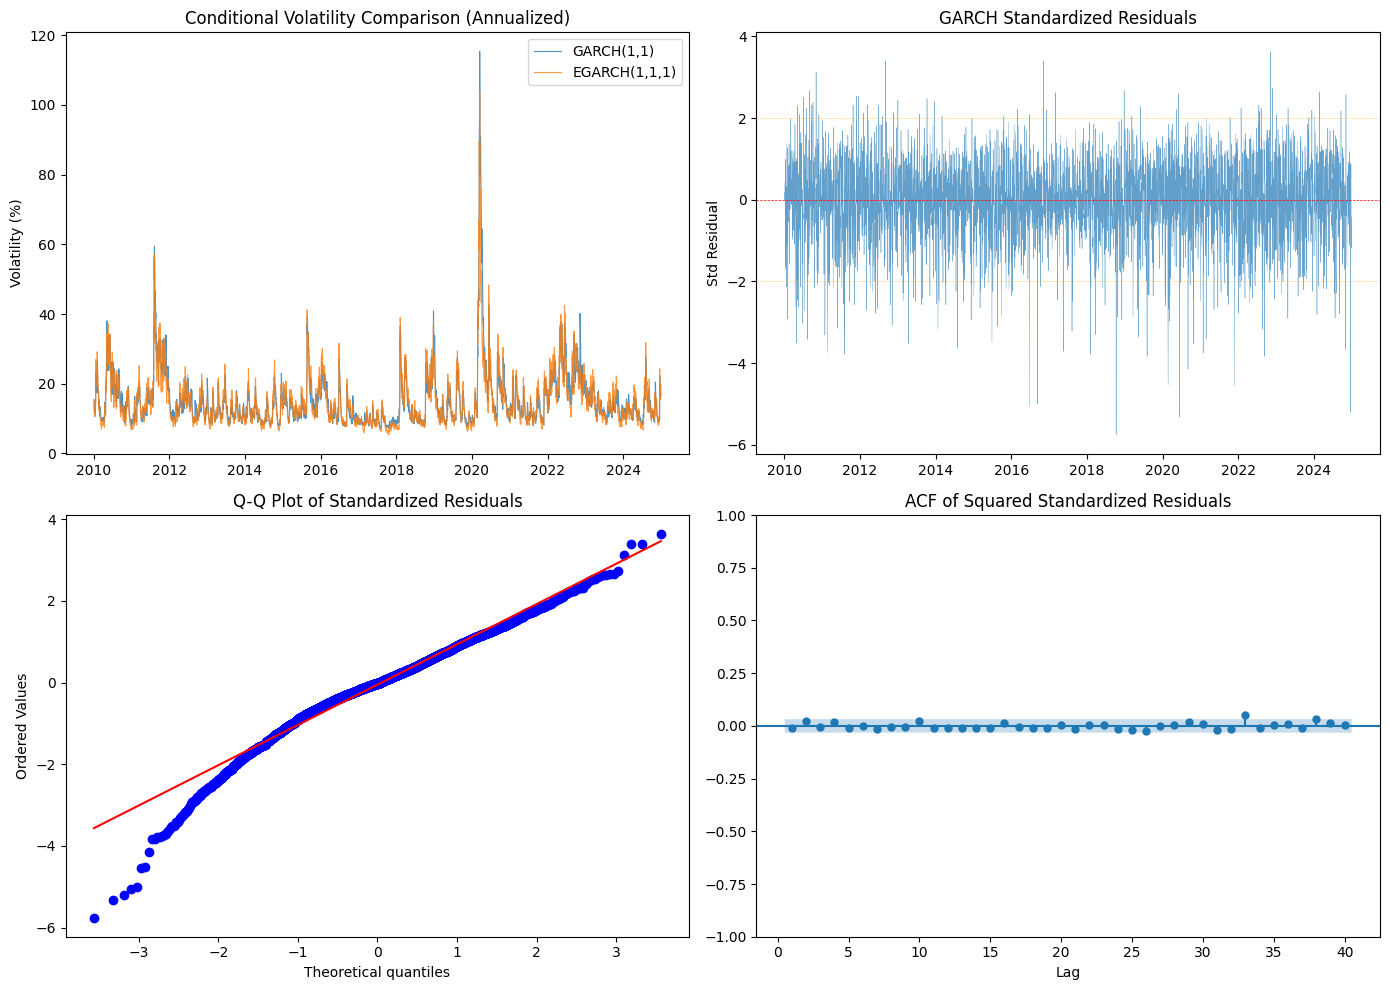

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Conditional volatility from both models
ax = axes[0, 0]
garch_vol = garch_result.conditional_volatility * np.sqrt(252)  # Annualized
egarch_vol = egarch_result.conditional_volatility * np.sqrt(252)
ax.plot(garch_vol.index, garch_vol.values, label="GARCH(1,1)", linewidth=0.8, alpha=0.8)
ax.plot(egarch_vol.index, egarch_vol.values, label="EGARCH(1,1,1)", linewidth=0.8, alpha=0.8)
ax.set_title("Conditional Volatility Comparison (Annualized)")
ax.set_ylabel("Volatility (%)")
ax.legend()

# Standardized residuals
ax = axes[0, 1]
std_resid = garch_result.std_resid
ax.plot(std_resid.index, std_resid.values, linewidth=0.3, alpha=0.7)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.axhline(2, color="orange", linestyle="--", linewidth=0.5, alpha=0.5)
ax.axhline(-2, color="orange", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_title("GARCH Standardized Residuals")
ax.set_ylabel("Std Residual")

# Q-Q plot of standardized residuals
ax = axes[1, 0]
probplot(std_resid.dropna(), dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Standardized Residuals")

# ACF of squared standardized residuals (should be white noise)
ax = axes[1, 1]
plot_acf(std_resid.dropna() ** 2, lags=40, zero=False, ax=ax)
ax.set_title("ACF of Squared Standardized Residuals")
ax.set_xlabel("Lag")

plt.tight_layout()
plt.show()

**Interpretation**: (a) GARCH and EGARCH conditional volatility track closely during
calm periods but diverge during drawdowns — EGARCH responds more aggressively to
negative shocks (the leverage effect). (b) Standardized residuals should look like
white noise with unit variance; persistent exceedances beyond ±2 suggest model
misspecification. (c) The Q-Q plot reveals fat tails — GARCH with a Normal
distribution underestimates extreme moves, motivating Student-t or skewed
distributions in production. (d) The ACF of squared standardized residuals should
be insignificant if the model captures all volatility clustering; remaining
significance at short lags suggests a higher-order specification might help.

## Rolling Volatility Forecasts

In practice, we use expanding or rolling windows to generate out-of-sample
volatility forecasts for risk management.

In [11]:
# Rolling 1-step ahead forecasts (simplified for speed)
forecast_start = len(returns) - 252

forecast_vol = []
actual_vol = []
forecast_dates = []

for t in range(forecast_start, len(returns) - 1):
    train_data = returns.iloc[: t + 1]

    # Fit GARCH on training data
    model = arch_model(train_data, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
    result = model.fit(disp="off", show_warning=False)

    # 1-step ahead forecast
    forecast = result.forecast(horizon=1)
    forecast_variance = forecast.variance.iloc[-1, 0]
    forecast_vol.append(np.sqrt(forecast_variance))

    # Actual realized volatility (next day's squared return as proxy)
    actual_vol.append(np.abs(returns.iloc[t + 1]))
    forecast_dates.append(returns.index[t + 1])

forecast_df = pd.DataFrame(
    {"forecast_vol": forecast_vol, "actual_vol": actual_vol}, index=pd.Index(forecast_dates)
)

print(f"Generated {len(forecast_df)} rolling forecasts")

Generated 251 rolling forecasts


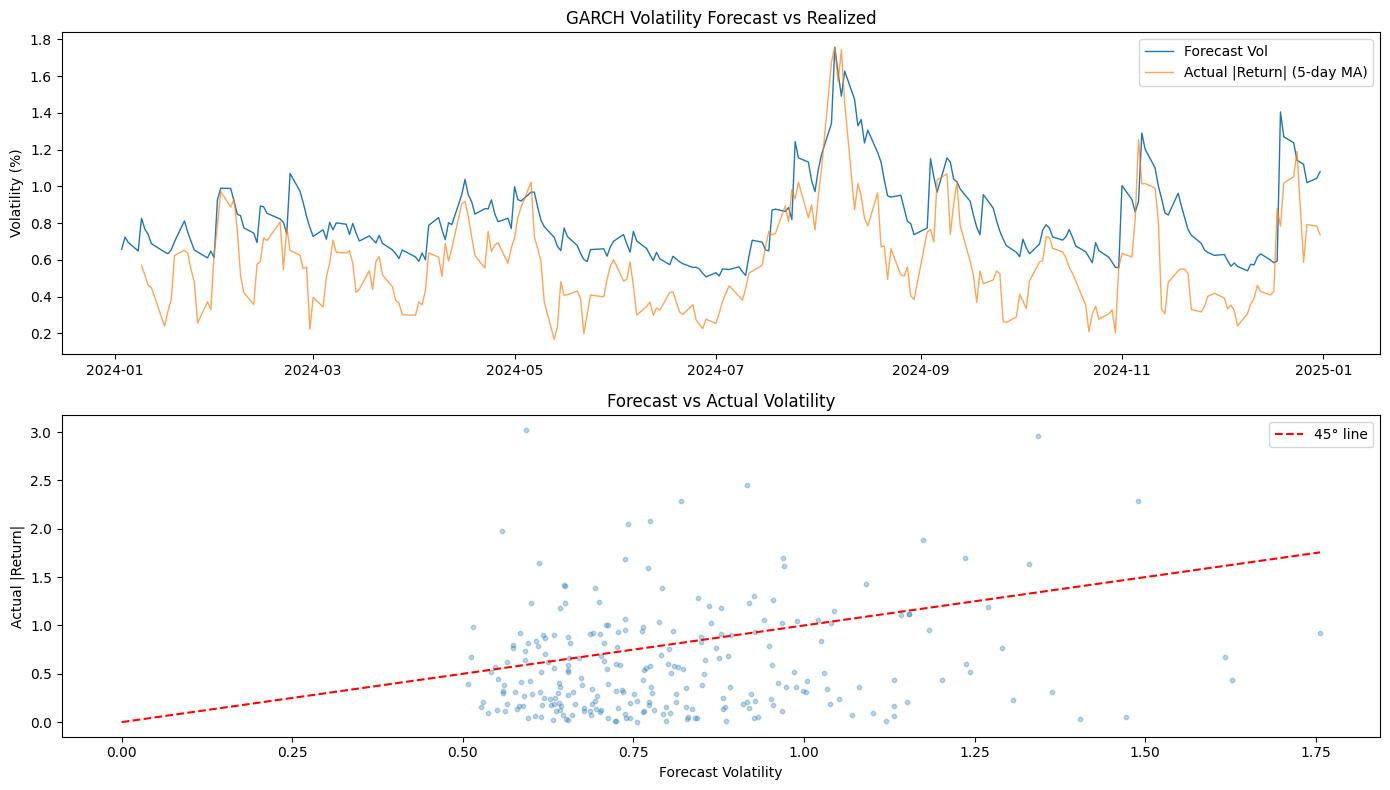

In [12]:
# Visualize forecast performance
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(forecast_df.index, forecast_df["forecast_vol"], label="Forecast Vol", linewidth=1)
ax.plot(
    forecast_df.index,
    forecast_df["actual_vol"].rolling(5).mean(),
    label="Actual |Return| (5-day MA)",
    linewidth=1,
    alpha=0.7,
)
ax.set_title("GARCH Volatility Forecast vs Realized")
ax.set_ylabel("Volatility (%)")
ax.legend()

# Scatter plot
ax = axes[1]
ax.scatter(forecast_df["forecast_vol"], forecast_df["actual_vol"], alpha=0.3, s=10)
ax.plot(
    [0, forecast_df["forecast_vol"].max()],
    [0, forecast_df["forecast_vol"].max()],
    "r--",
    label="45° line",
)
ax.set_xlabel("Forecast Volatility")
ax.set_ylabel("Actual |Return|")
ax.set_title("Forecast vs Actual Volatility")
ax.legend()

plt.tight_layout()
plt.show()

## Risk Management Application: Value at Risk (VaR)

GARCH volatility forecasts are directly used for VaR calculation:
VaR_α = μ + σ_t * z_α

Where z_α is the quantile of the assumed distribution.

In [13]:
# Calculate 1-day 95% and 99% VaR using GARCH forecast
confidence_levels = [0.95, 0.99]
z_scores = {0.95: -1.645, 0.99: -2.326}  # For normal distribution

# Use the last GARCH forecast
last_forecast = garch_result.forecast(horizon=1)
forecast_mean = last_forecast.mean.iloc[-1, 0]
forecast_vol = np.sqrt(last_forecast.variance.iloc[-1, 0])

print("=== Value at Risk Calculation ===")
print(f"Forecast mean: {forecast_mean:.4f}%")
print(f"Forecast volatility: {forecast_vol:.4f}%")
print()

for conf in confidence_levels:
    var = forecast_mean + forecast_vol * z_scores[conf]
    print(f"1-day {int(conf * 100)}% VaR: {var:.2f}%")
    print(
        f"  → A $1M portfolio could lose more than ${-var * 10000:.0f} with {int((1 - conf) * 100)}% probability"
    )
    print()

=== Value at Risk Calculation ===
Forecast mean: 0.0863%
Forecast volatility: 1.0016%

1-day 95% VaR: -1.56%
  → A $1M portfolio could lose more than $15613 with 5% probability

1-day 99% VaR: -2.24%
  → A $1M portfolio could lose more than $22434 with 1% probability



## Summary Statistics for Chapter

In [14]:
summary = {
    "Data observations": len(returns),
    "Date range": f"{returns.index.min().date()} to {returns.index.max().date()}",
    "Return mean (daily %)": f"{returns.mean():.4f}",
    "Return std (daily %)": f"{returns.std():.4f}",
    "ARCH test p-value": f"{arch_test[1]:.6f}",
    "GARCH(1,1) alpha": f"{alpha:.4f}",
    "GARCH(1,1) beta": f"{beta:.4f}",
    "Persistence (alpha+beta)": f"{alpha + beta:.4f}",
    "Unconditional vol (ann)": f"{np.sqrt(omega / (1 - alpha - beta)) * np.sqrt(252):.2f}%",
    "GARCH AIC": f"{garch_result.aic:.2f}",
    "EGARCH AIC": f"{egarch_result.aic:.2f}",
}

print("\n=== Summary for Chapter ===")
for key, value in summary.items():
    print(f"{key}: {value}")


=== Summary for Chapter ===
Data observations: 3773
Date range: 2010-01-05 to 2024-12-31
Return mean (daily %): 0.0509
Return std (daily %): 1.0772
ARCH test p-value: 0.000000
GARCH(1,1) alpha: 0.1691
GARCH(1,1) beta: 0.7988
Persistence (alpha+beta): 0.9679
Unconditional vol (ann): 17.18%
GARCH AIC: 9652.25
EGARCH AIC: 9490.96


## Volatility Feature Engineering with ml4t-engineer

The `arch` library is designed for econometric estimation — fitting models,
running diagnostics, and producing forecasts. For **feature engineering** at
scale (across many symbols in a Polars DataFrame), `ml4t-engineer` provides
volatility functions as Polars expressions that run inside `with_columns()`.

This section demonstrates the full volatility feature toolkit: GARCH forecasts,
EWMA, realized volatility, vol-of-vol, percentile rank, and regime indicators.

### TA-lib vs ml4t-engineer

TA-lib provides traditional indicators (ATR, Bollinger Bands, RSI) but
has no support for:
- GARCH conditional volatility forecasts
- Range-based estimators (Parkinson, Garman-Klass) — see NB09
- Volatility regime classification
- Vol-of-vol (volatility clustering measure)

`ml4t-engineer` fills this gap with Polars-native implementations that
integrate directly into DataFrame pipelines — no C dependency required.

In [15]:
# Build a Polars DataFrame with returns for ml4t-engineer
spy_returns = (
    etf_filtered.filter(pl.col("symbol") == SYMBOL)
    .select(["timestamp", "close"])
    .with_columns(returns=pl.col("close").pct_change())
    .drop_nulls()
)

# All volatility features in a single with_columns call
spy_vol_features = spy_returns.with_columns(
    rv_21=realized_volatility("returns", period=21),
    ewma_vol=ewma_volatility("close", span=120),
    garch_vol=garch_forecast("returns", horizon=1, alpha=alpha, beta=beta),
    vol_of_vol=volatility_of_volatility("close", vol_period=21),
    vol_pctile=volatility_percentile_rank("returns", period=60),
)

# volatility_regime_probability returns a dict of expressions
vol_regime_exprs = volatility_regime_probability("returns")
spy_vol_features = spy_vol_features.with_columns(**vol_regime_exprs)

print(f"Volatility features: {spy_vol_features.shape}")
spy_vol_features.select(
    ["timestamp", "rv_21", "ewma_vol", "garch_vol", "vol_of_vol", "vol_pctile"]
).tail(5)

Volatility features: (3773, 12)


timestamp,rv_21,ewma_vol,garch_vol,vol_of_vol,vol_pctile
date,f64,f64,f64,f64,f64
2024-12-24,0.136351,0.008303,0.012779,3.871925,40.873016
2024-12-26,0.135997,0.008269,0.012742,3.872326,40.873016
2024-12-27,0.139988,0.00829,0.01189,3.872193,95.238095
2024-12-30,0.145005,0.008321,0.011948,3.871768,95.634921
2024-12-31,0.143134,0.008293,0.012126,3.80792,96.031746


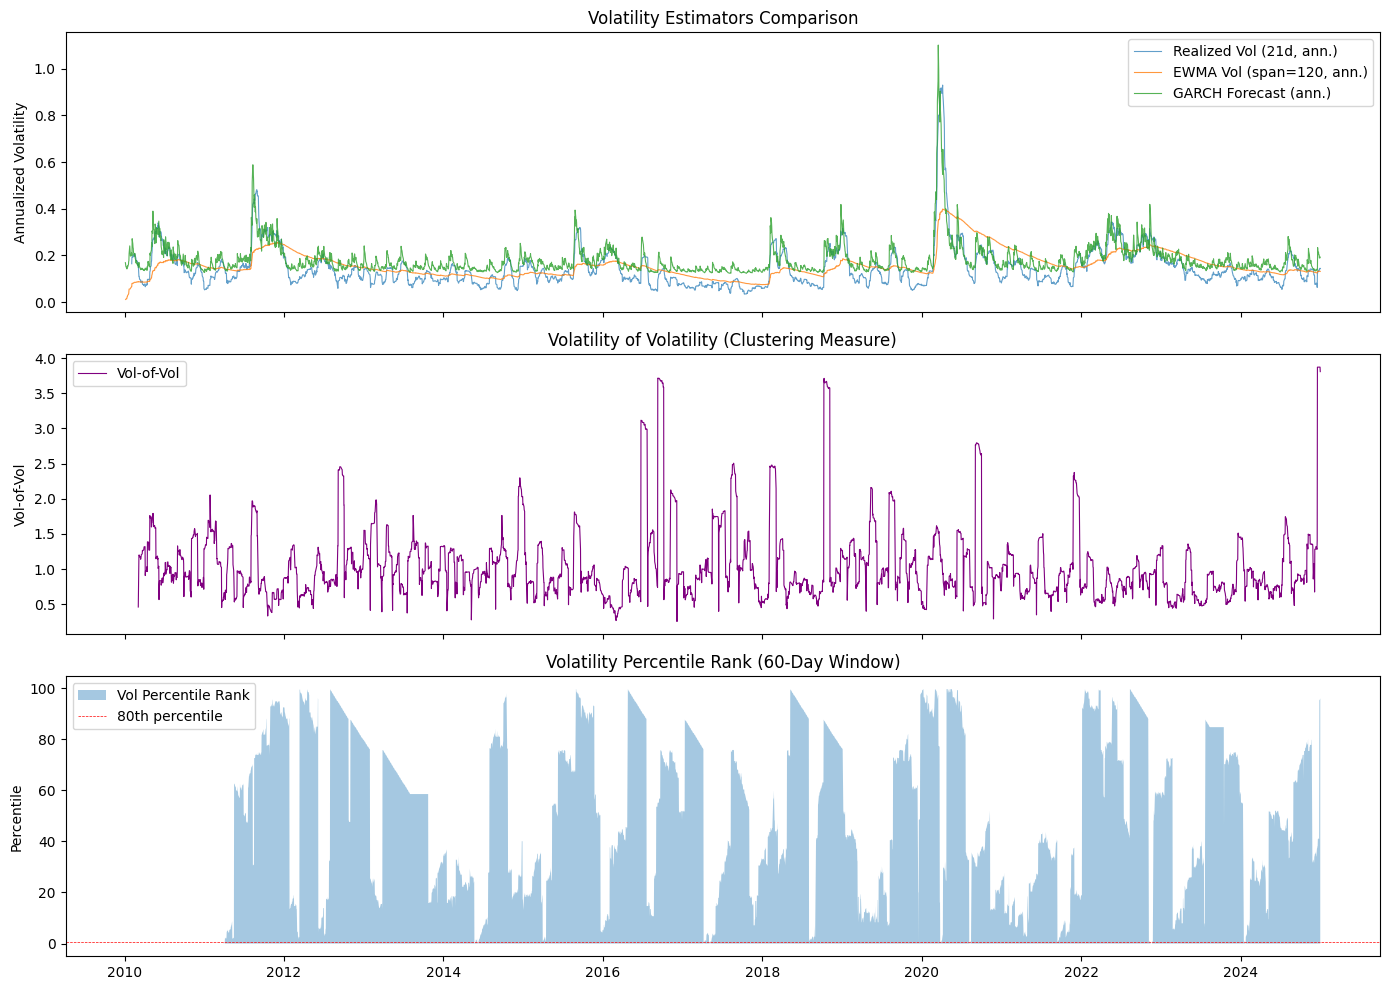

In [16]:
# Visualize the feature suite
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

vf_pd = spy_vol_features.to_pandas().set_index("timestamp")

ax = axes[0]
# realized_volatility() annualizes by default (×√252); ewma_volatility() and
# garch_forecast() return daily-scale values. Annualize the latter two on the
# plot so all three sit on the same y-axis.
ann = np.sqrt(252)
ax.plot(vf_pd.index, vf_pd["rv_21"], label="Realized Vol (21d, ann.)", linewidth=0.8, alpha=0.7)
ax.plot(
    vf_pd.index,
    vf_pd["ewma_vol"] * ann,
    label="EWMA Vol (span=120, ann.)",
    linewidth=0.8,
    alpha=0.8,
)
ax.plot(
    vf_pd.index,
    vf_pd["garch_vol"] * ann,
    label="GARCH Forecast (ann.)",
    linewidth=0.8,
    alpha=0.8,
)
ax.set_title("Volatility Estimators Comparison")
ax.set_ylabel("Annualized Volatility")
ax.legend()

ax = axes[1]
ax.plot(vf_pd.index, vf_pd["vol_of_vol"], label="Vol-of-Vol", linewidth=0.8, color="purple")
ax.set_title("Volatility of Volatility (Clustering Measure)")
ax.set_ylabel("Vol-of-Vol")
ax.legend()

ax = axes[2]
ax.fill_between(vf_pd.index, 0, vf_pd["vol_pctile"], alpha=0.4, label="Vol Percentile Rank")
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.5, label="80th percentile")
ax.set_title("Volatility Percentile Rank (60-Day Window)")
ax.set_ylabel("Percentile")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**: The three volatility estimators capture different dynamics.
Realized vol is noisy but unbiased; EWMA provides smooth exponential decay;
GARCH adapts to the persistence structure. Vol-of-vol spikes during regime
transitions (COVID, 2022 rate hikes), while the percentile rank maps volatility
to a stationary [0, 1] scale useful as a direct ML feature.

## Save Volatility Forecasts for Downstream Chapters

GARCH volatility forecasts are consumed by:
- Chapter 7: Feature engineering (volatility-adjusted features)
- Chapter 18: Strategy simulation (position sizing)
- Chapter 21: Risk management (VaR, position limits)

In [17]:
# Process all symbols and save multi-symbol volatility forecasts
MODEL_DIR = get_case_study_dir("etfs") / "models" / "time_series"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "=" * 60)
print("MULTI-SYMBOL GARCH VOLATILITY FORECASTING")
print("=" * 60)


def fit_garch_for_symbol(symbol: str) -> tuple[pl.DataFrame | None, dict]:
    """Fit GARCH and return (forecast DataFrame or None, summary dict)."""
    summary = {
        "symbol": symbol,
        "n_obs": 0,
        "alpha": float("nan"),
        "beta": float("nan"),
        "persistence": float("nan"),
        "status": "ok",
    }
    symbol_returns = load_symbol_returns(symbol)
    if symbol_returns is None or len(symbol_returns) < 500:
        summary["status"] = "insufficient_data"
        return None, summary

    try:
        model = arch_model(symbol_returns, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
        result = model.fit(disp="off", show_warning=False)
    except (ValueError, np.linalg.LinAlgError) as exc:
        summary["status"] = f"fit_failed: {type(exc).__name__}"
        return None, summary

    cond_vol = result.conditional_volatility
    alpha_s = result.params.get("alpha[1]", 0)
    beta_s = result.params.get("beta[1]", 0)
    summary.update(n_obs=len(cond_vol), alpha=alpha_s, beta=beta_s, persistence=alpha_s + beta_s)

    pred_df = pl.DataFrame(
        {
            "timestamp": cond_vol.index.values,
            "symbol": symbol,
            "realized_vol": (symbol_returns.rolling(21).std() * np.sqrt(252)).values,
            "garch_forecast": (cond_vol * np.sqrt(252)).values,  # Annualized
        }
    ).drop_nulls()
    return pred_df, summary


# Process all symbols
all_vol = []
fit_summaries = []
print(f"Processing {len(SYMBOLS)} symbols...")

for symbol in SYMBOLS:
    pred_df, summary = fit_garch_for_symbol(symbol)
    fit_summaries.append(summary)
    if pred_df is not None:
        all_vol.append(pred_df)

fit_summary_df = pd.DataFrame(fit_summaries)
display(fit_summary_df.sort_values("persistence", ascending=False, na_position="last"))

# Combine and save
if all_vol:
    vol_df = pl.concat(all_vol)
    output_path = MODEL_DIR / "garch_volatility.parquet"
    vol_df.write_parquet(output_path)

    print(f"Saved multi-symbol volatility forecasts to {output_path}")
    print(f"  Shape: {vol_df.shape}")
    print(f"  Assets: {vol_df['symbol'].n_unique()}")
    print(f"  Date range: {vol_df['timestamp'].min()} to {vol_df['timestamp'].max()}")
    print(
        f"  Mean persistence: {fit_summary_df['persistence'].mean():.4f}; "
        f"min: {fit_summary_df['persistence'].min():.4f}; "
        f"max: {fit_summary_df['persistence'].max():.4f}"
    )
else:
    print("WARNING: No volatility forecasts generated")


MULTI-SYMBOL GARCH VOLATILITY FORECASTING
Processing 100 symbols...


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08965. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000283. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleW

.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0924. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09562. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006999. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0339. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


,symbol,n_obs,alpha,beta,persistence,status
50,JNK,3773,0.176184,0.823816,1.000000,ok
36,HYG,3773,0.161971,0.836165,0.998136,ok
57,OIH,3773,0.071559,0.926229,0.997789,ok
72,UNG,3773,0.075402,0.920368,0.995771,ok
30,FXE,3773,0.034365,0.961334,0.995699,ok
...,...,...,...,...,...,...
93,XLP,3773,0.132272,0.821496,0.953767,ok
41,IEMG,3064,0.117156,0.834723,0.951879,ok
28,EZA,3773,0.088441,0.862254,0.950694,ok
90,XLF,3773,0.164997,0.785197,0.950195,ok


Saved multi-symbol volatility forecasts to case_studies/etfs/models/time_series/garch_volatility.parquet
  Shape: (366608, 4)
  Assets: 100
  Date range: 2010-01-05 00:00:00 to 2024-12-31 00:00:00
  Mean persistence: 0.9781; min: 0.9480; max: 1.0000


## Key Takeaways

1. **GARCH models forecast volatility, not returns** — use for risk, not alpha
2. **GARCH(1,1) captures most volatility dynamics** — higher orders rarely help
3. **EGARCH captures leverage effect** — negative shocks increase volatility more
4. **Persistence (α+β) near 1** is typical for financial data — volatility is sticky
5. **VaR calculation is a direct application** — multiply forecast σ by z-score
6. **Model residuals should be white noise** — check squared standardized residuals
7. **ml4t-diagnostic streamlines testing**: `arch_lm_test()` and `fit_garch()`
   replace boilerplate statsmodels/arch code for multi-symbol pipelines
8. **ml4t-engineer provides Polars-native vol features**: `garch_forecast()`,
   `realized_volatility()`, `ewma_volatility()`, `volatility_regime_probability()`
   — all composable inside a single `with_columns()` call